<a href="https://colab.research.google.com/github/boseupama/Scan_Conversion_UB/blob/main/UB_Bresenhams_lineDrawing_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Bresenham's Line Drawing Algorithm
import matplotlib.pyplot as plt
def get_line_points(x1, y1, x2, y2):
    pixels = []

    print("Using Bresenham's Line Drawing Algorithm\n")
    print("Starting Point:", (x1, y1))
    print("Ending Point:", (x2, y2))
    dx = x2 - x1
    dy = y2 - y1

    print("dx =", dx)
    print("dy =", dy)

    # vertical line
    if dx == 0:
        print("\nCase: Vertical Line.")

        start_y = min(y1, y2)
        end_y = max(y1, y2)

        for y in range(start_y, end_y + 1):
            pixels.append((x1, y))

            print(
                "x =", x1,
                "y =", y,
                "pixels =", (x1, y)
            )

        return pixels

    #horizontal line
    if dy == 0:
        print("\nCase: Horizontal Line.")

        start_x = min(x1, x2)
        end_x = max(x1, x2)

        for x in range(start_x, end_x + 1):
            pixels.append((x, y1))

            print(
                "x =", x,
                "y =", y1,
                "pixels =", (x, y1)
            )

        return pixels

    # Bresenham's for positive slope
    if dy > 0:

        # Shallow line: 0 < slope < 1
        if abs(dy) <= abs(dx):

            print("\nCase: Positive Shallow Line.")
            print("Condition: |dy| <= |dx|")

            #x increase from left to right
            if x1 > x2:
                x1, x2 = x2, x1
                y1, y2 = y2, y1

            dx = x2 - x1
            dy = y2 - y1

            p = 2 * dy - dx

            print("Initial Decision Parameter:", p)
            print()

            x = x1
            y = y1

            for i in range(dx + 1):

                pixels.append((x, y))

                print(
                    "Step =", i,
                    "x =", x,
                    "y =", y,
                    "p =", p,
                    "pixels =", (x, y)
                )

                if p < 0:
                    #to choose East pixel
                    p = p + 2 * dy

                    print("  Decision: Choose E")
                    print("  New p =", p)

                else:
                    #to choose North-East pixel
                    y = y + 1
                    p = p + 2 * dy - 2 * dx

                    print("  Decision: Choose NE")
                    print("  New p =", p)

                x = x + 1

        # Steep line: slope > 1
        else:

            print("\nCase: Positive Steep Line.")
            print("Condition: |dy| > |dx|")

            #y increase from bottom to top
            if y1 > y2:
                x1, x2 = x2, x1
                y1, y2 = y2, y1

            dx = x2 - x1
            dy = y2 - y1

            p = 2 * dx - dy

            print("Initial Decision Parameter:", p)
            print()

            x = x1
            y = y1

            for i in range(dy + 1):

                pixels.append((x, y))

                print(
                    "Step =", i,
                    "x =", x,
                    "y =", y,
                    "p =", p,
                    "pixels =", (x, y)
                )

                if p < 0:
                    # Choose North pixel
                    p = p + 2 * dx

                    print("  Decision: Choose N")
                    print("  New p =", p)

                else:
                    # Choose North-East pixel
                    x = x + 1
                    p = p + 2 * dx - 2 * dy

                    print("  Decision: Choose NE")
                    print("  New p =", p)

                y = y + 1

    # Bresenham for negative slope
    else:

        # Shallow negative line
        if abs(dy) <= abs(dx):

            print("\nCase: Negative Shallow Line.")
            print("Condition: |dy| <= |dx|")

            #x increase from left to right
            if x1 > x2:
                x1, x2 = x2, x1
                y1, y2 = y2, y1

            dx = x2 - x1
            dy = abs(y2 - y1)

            p = 2 * dy - dx

            print("Initial Decision Parameter:", p)
            print()

            x = x1
            y = y1

            #to determine direction of y
            y_step = 1 if y2 > y1 else -1

            for i in range(dx + 1):

                pixels.append((x, y))

                print(
                    "Step =", i,
                    "x =", x,
                    "y =", y,
                    "p =", p,
                    "pixels =", (x, y)
                )
                if p < 0:
                    p = p + 2 * dy
                    print("  Decision: Choose E")
                    print("  New p =", p)

                else:
                    y = y + y_step
                    p = p + 2 * dy - 2 * dx
                    print("  Decision: Choose SE")
                    print("  New p =", p)
                x = x + 1
        # Steep negative line
        else:
            print("\nCase: Negative Steep Line.")
            print("Condition: |dy| > |dx|")
            #y decrease/increase consistently
            if y1 < y2:
                x1, x2 = x2, x1
                y1, y2 = y2, y1
            dx = abs(x2 - x1)
            dy = abs(y2 - y1)
            p = 2 * dx - dy
            print("Initial Decision Parameter:", p)
            print()
            x = x1
            y = y1

            #to determine direction of x
            x_step = 1 if x2 > x1 else -1

            for i in range(dy + 1):

                pixels.append((x, y))

                print(
                    "Step =", i,
                    "x =", x,
                    "y =", y,
                    "p =", p,
                    "pixels =", (x, y)
                )

                if p < 0:

                    p = p + 2 * dx

                    print("  Decision: Choose S")
                    print("  New p =", p)

                else:

                    x = x + x_step
                    p = p + 2 * dx - 2 * dy

                    print("  Decision: Choose SW")
                    print("  New p =", p)
                y = y - 1

    return pixels





In [ ]:
def plot_line(pixels, x1, y1, x2, y2):

    xs = [p[0] for p in pixels]
    ys = [p[1] for p in pixels]
    plt.figure(figsize=(7, 6))
    # Draw line
    plt.plot(
        xs,
        ys,
        color="blue",
        linewidth=1,
        label="Bresenham Line"
    )
    # Show calculated pixels
    plt.scatter(
        xs,
        ys,
        color="red",
        s=35,
        zorder=5,
        label="Computed Pixels"
    )
    # Show start and end points
    plt.scatter(
        [x1, x2],
        [y1, y2],
        color="green",
        s=100,
        marker="o",
        zorder=6,
        label="Start / End"
    )
    plt.title("Line Drawing using Bresenham's Algorithm")
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")

    plt.axhline(
        0,
        color="gray",
        linewidth=0.5
    )
    plt.axvline(
        0,
        color="gray",
        linewidth=0.5
    )
    plt.grid(
        True,
        linestyle="--",
        alpha=0.6
    )
    plt.legend()
    plt.axis("equal")
    plt.savefig(
        "bresenham_line_plot.png",
        dpi=150
    )
    print("\nPlot saved as 'bresenham_line_plot.png'")
    plt.show()



Enter the starting point:
  x1 = 9
  y1 = 18

Enter the ending point:
  x2 = 14
  y2 = 22
Using Bresenham's Line Drawing Algorithm

Starting Point: (9, 18)
Ending Point: (14, 22)
dx = 5
dy = 4

Case: Positive Shallow Line.
Condition: |dy| <= |dx|
Initial Decision Parameter: 3

Step = 0 x = 9 y = 18 p = 3 pixels = (9, 18)
  Decision: Choose NE
  New p = 1
Step = 1 x = 10 y = 19 p = 1 pixels = (10, 19)
  Decision: Choose NE
  New p = -1
Step = 2 x = 11 y = 20 p = -1 pixels = (11, 20)
  Decision: Choose E
  New p = 7
Step = 3 x = 12 y = 20 p = 7 pixels = (12, 20)
  Decision: Choose NE
  New p = 5
Step = 4 x = 13 y = 21 p = 5 pixels = (13, 21)
  Decision: Choose NE
  New p = 3
Step = 5 x = 14 y = 22 p = 3 pixels = (14, 22)
  Decision: Choose NE
  New p = 1

Plot saved as 'bresenham_line_plot.png'


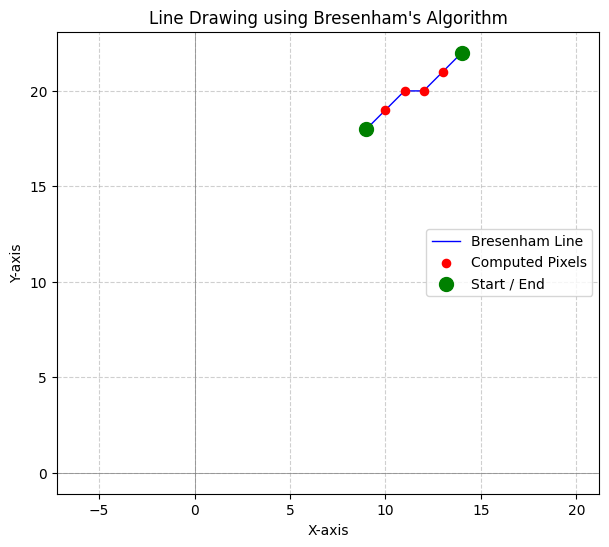

In [ ]:
def main():

    print("Enter the starting point:")
    x1 = int(input("  x1 = "))
    y1 = int(input("  y1 = "))

    print("\nEnter the ending point:")
    x2 = int(input("  x2 = "))
    y2 = int(input("  y2 = "))

    pixels = get_line_points(
        x1, y1, x2, y2
    )

    plot_line(
        pixels,
        x1, y1,
        x2, y2
    )


if __name__ == "__main__":
    main()